# Exploratory Data Analysis — AQI Forecasting for Hyderabad, Sindh, Pakistan




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

df = pd.read_csv("data.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)
df.head()

,timestamp,aqi,pm25,pm10,o3,no2,so2,co,temp,humidity,pressure,wind_speed,clouds
0,2024-08-22 00:00:00+00:00,64,15.0,39.0,33.0,7.0,5.3,154.0,26.9,86,1000.4,18.5,1
1,2024-08-22 01:00:00+00:00,64,15.2,41.2,34.0,6.5,5.4,157.0,27.3,85,1000.3,17.6,56
2,2024-08-22 02:00:00+00:00,65,15.8,43.2,37.0,5.7,5.6,161.0,27.8,81,1000.7,19.1,32
3,2024-08-22 03:00:00+00:00,65,16.3,49.8,42.0,4.8,5.7,163.0,28.9,74,1001.1,17.2,12
4,2024-08-22 04:00:00+00:00,65,16.9,57.4,53.0,3.8,5.8,161.0,30.1,71,1001.0,16.9,4


## 1. Basic shape and data quality

In [ ]:
print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['timestamp'].min()} -> {df['timestamp'].max()}")
print(f"Span: {(df['timestamp'].max() - df['timestamp'].min()).days} days")

Rows: 17,544
Columns: ['timestamp', 'aqi', 'pm25', 'pm10', 'o3', 'no2', 'so2', 'co', 'temp', 'humidity', 'pressure', 'wind_speed', 'clouds']
Date range: 2024-08-22 00:00:00+00:00 -> 2026-08-22 23:00:00+00:00
Span: 730 days


In [ ]:
print("Missing values per column:")
df.isna().sum()

Missing values per column:


,0
timestamp,0
aqi,0
pm25,0
pm10,0
o3,0
no2,0
so2,0
co,0
temp,0
humidity,0


In [ ]:
df.describe().round(2)

,aqi,pm25,pm10,o3,no2,so2,co,temp,humidity,pressure,wind_speed,clouds
count,17544.00,17544.00,17544.00,17544.00,17544.00,17544.00,17544.00,17544.00,17544.00,17544.00,17544.00,17544.00
mean,88.19,28.04,53.47,80.31,8.63,7.16,492.94,27.59,53.64,1004.49,12.24,24.17
std,24.59,14.60,31.01,33.99,8.04,3.19,420.28,7.12,22.05,7.10,5.94,37.76
min,36.00,3.50,4.30,12.00,0.00,0.80,80.00,7.30,4.00,987.00,0.00,0.00
25%,71.00,17.90,33.50,52.00,3.00,5.10,223.00,23.30,36.00,998.60,7.60,0.00
50%,82.00,24.40,46.80,73.00,6.20,6.70,331.00,28.20,53.00,1004.20,12.00,1.00
75%,98.00,34.20,65.70,106.00,10.90,8.80,628.00,32.50,73.00,1010.40,16.70,38.00
max,173.00,105.50,560.70,182.00,57.60,29.90,4083.00,46.60,100.00,1022.30,35.30,100.00


**Takeaway:** the dataset is complete — zero missing values across
17,500+ hourly rows spanning the full 2-year window — a solid
foundation to train on.

## 2. AQI category breakdown

In [ ]:
def aqi_category(a):
    if a <= 50: return "Good"
    if a <= 100: return "Moderate"
    if a <= 150: return "Unhealthy (Sensitive)"
    if a <= 200: return "Unhealthy"
    if a <= 300: return "Very Unhealthy"
    return "Hazardous"

df["category"] = df["aqi"].apply(aqi_category)
category_order = ["Good", "Moderate", "Unhealthy (Sensitive)", "Unhealthy", "Very Unhealthy", "Hazardous"]
counts = df["category"].value_counts().reindex(category_order).dropna()
pct = (counts / len(df) * 100).round(1)

print(counts)
print()
print(pct)

category
Good                        93.0
Moderate                 13421.0
Unhealthy (Sensitive)     3377.0
Unhealthy                  653.0
Name: count, dtype: float64

category
Good                      0.5
Moderate                 76.5
Unhealthy (Sensitive)    19.2
Unhealthy                 3.7
Name: count, dtype: float64


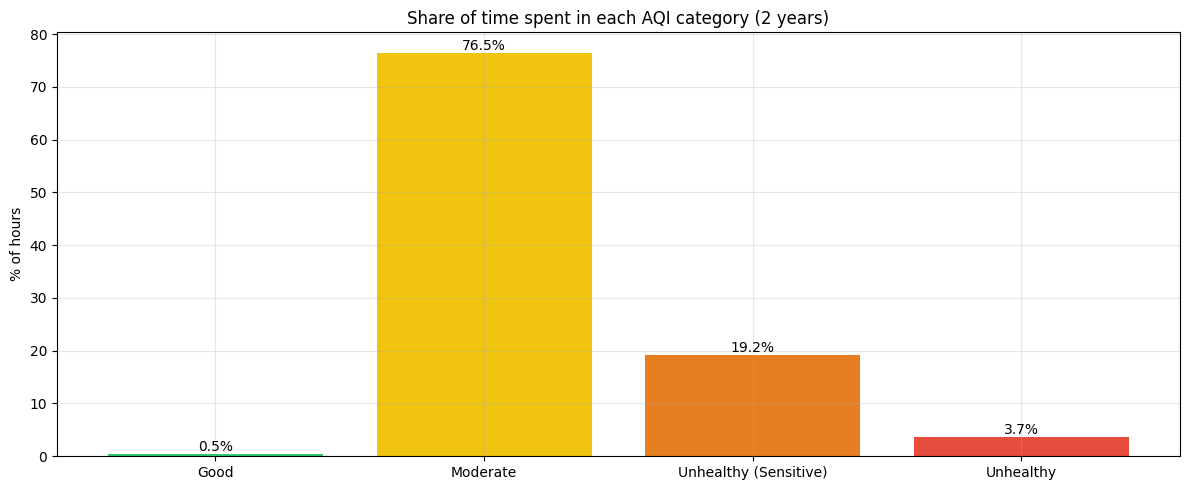

In [ ]:
colors = {"Good": "#2ecc71", "Moderate": "#f1c40f", "Unhealthy (Sensitive)": "#e67e22",
          "Unhealthy": "#e74c3c", "Very Unhealthy": "#8e44ad", "Hazardous": "#7f0000"}

fig, ax = plt.subplots()
bars = ax.bar(pct.index, pct.values, color=[colors[c] for c in pct.index])
ax.set_ylabel("% of hours")
ax.set_title("Share of time spent in each AQI category (2 years)")
for bar, val in zip(bars, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, f"{val}%", ha="center")
plt.tight_layout()
plt.show()

**Takeaway:** air quality is "Moderate" roughly 3 out of 4 hours, but
nearly a quarter of all hours cross into Unhealthy-for-sensitive-groups
or worse — this is the practical justification for the dashboard's
hazardous-AQI alert banner.

## 3. AQI trend over the full 2 years

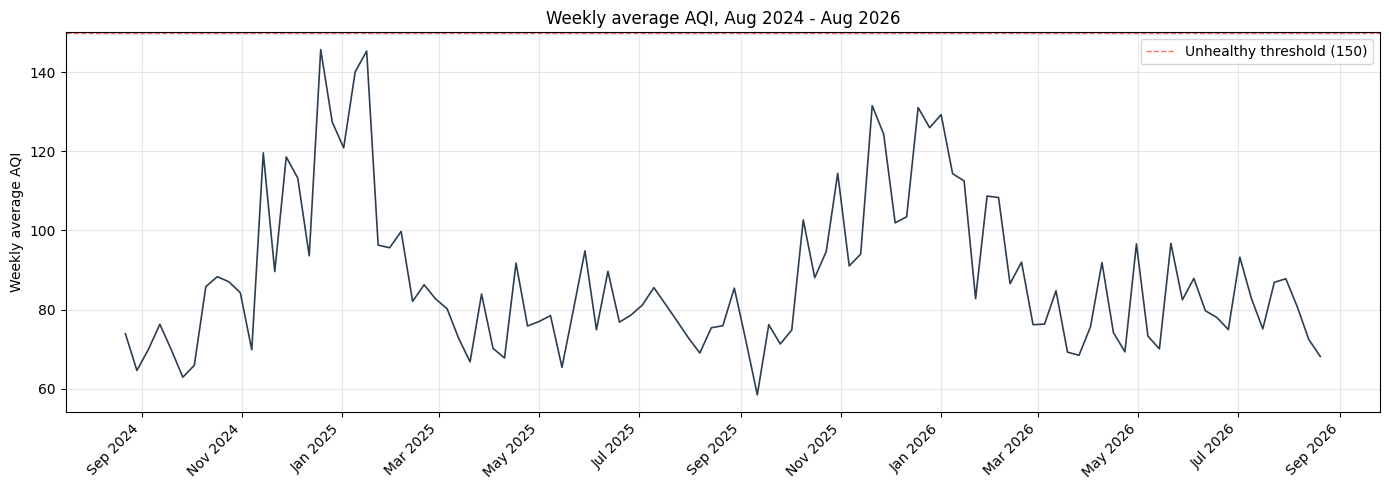

In [ ]:
weekly = df.set_index("timestamp").resample("7D")["aqi"].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(weekly.index, weekly.values, linewidth=1.2, color="#2c3e50")
ax.axhline(150, color="red", linestyle="--", linewidth=1, alpha=0.6, label="Unhealthy threshold (150)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha="right")
ax.set_ylabel("Weekly average AQI")
ax.set_title("Weekly average AQI, Aug 2024 - Aug 2026")
ax.legend()
plt.tight_layout()
plt.show()

**Takeaway:** two clear pollution peaks are visible, both around the
winter months (late 2024 and especially Jan 2026, where weekly
averages exceeded 140). This hints strongly at seasonality, explored
next.

## 4. Seasonality — average AQI by calendar month

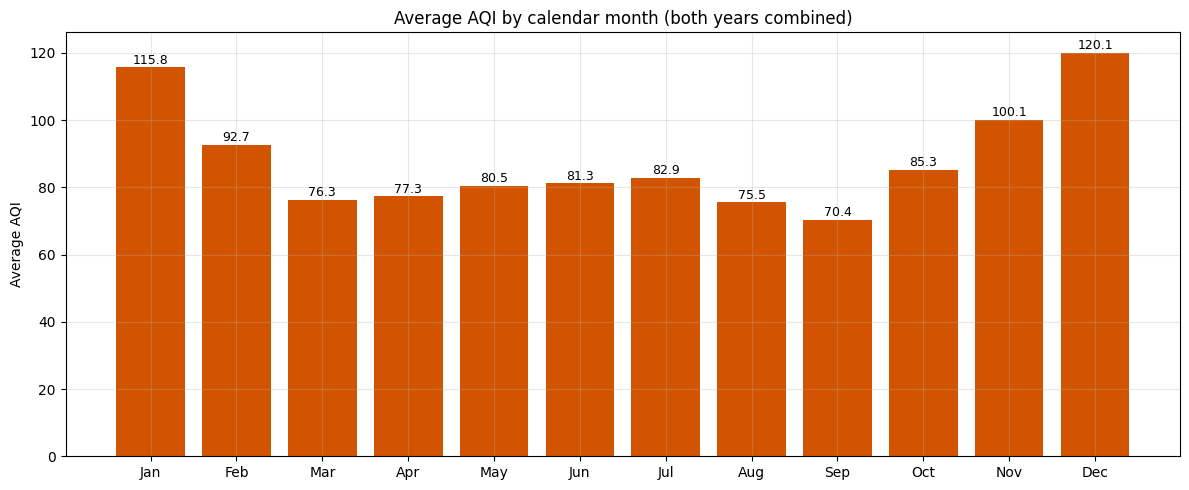

,month_num,month_name,aqi
0,1,Jan,115.8
1,2,Feb,92.7
2,3,Mar,76.3
3,4,Apr,77.3
4,5,May,80.5
5,6,Jun,81.3
6,7,Jul,82.9
7,8,Aug,75.5
8,9,Sep,70.4
9,10,Oct,85.3


In [ ]:
df["month_num"] = df["timestamp"].dt.month
df["month_name"] = df["timestamp"].dt.strftime("%b")

monthly = (df.groupby(["month_num", "month_name"])["aqi"]
             .mean().round(1).reset_index().sort_values("month_num"))

fig, ax = plt.subplots()
bars = ax.bar(monthly["month_name"], monthly["aqi"], color="#d35400")
ax.set_ylabel("Average AQI")
ax.set_title("Average AQI by calendar month (both years combined)")
for bar, val in zip(bars, monthly["aqi"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f"{val}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

monthly

**Takeaway:** December and January are clearly the worst months
(AQI ~116-120), while September is the cleanest (~70). This matches
the well-documented winter pollution pattern across Pakistan and
northern India, driven by temperature inversions that trap pollutants
close to the ground during cooler months. This justifies keeping
`month` as a model feature.

## 5. Daily rhythm — average AQI by hour of day (local time)

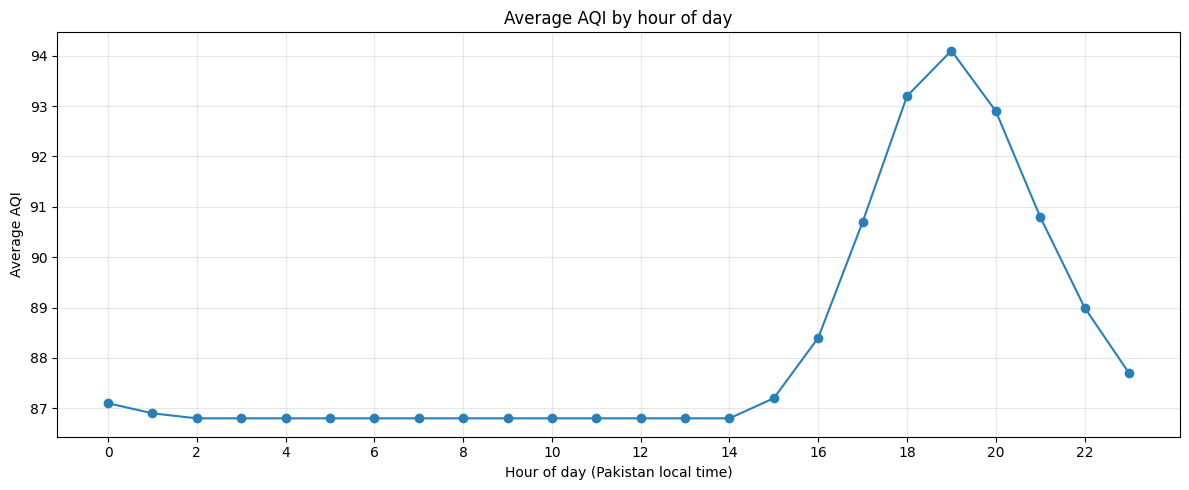

In [ ]:
# Open-Meteo timestamps are UTC; Pakistan is UTC+5
df["local_time"] = df["timestamp"] + pd.Timedelta(hours=5)
df["local_hour"] = df["local_time"].dt.hour

hourly = df.groupby("local_hour")["aqi"].mean().round(1)

fig, ax = plt.subplots()
ax.plot(hourly.index, hourly.values, marker="o", color="#2980b9")
ax.set_xlabel("Hour of day (Pakistan local time)")
ax.set_ylabel("Average AQI")
ax.set_title("Average AQI by hour of day")
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

**Takeaway:** AQI is fairly flat overnight through early afternoon,
then rises noticeably in the evening (peaking around 7-8pm local time)
— consistent with evening traffic and cooking-time emissions. Worth
noting: the very flat overnight stretch suggests the underlying
Open-Meteo/CAMS model data is somewhat smoothed at the hourly level
compared to a real ground sensor, which is useful context when
interpreting how much signal the lag/rolling features can extract.

## 6. What actually correlates with AQI?

In [ ]:
numeric_cols = ["aqi", "pm25", "pm10", "o3", "no2", "so2", "co",
                 "temp", "humidity", "pressure", "wind_speed", "clouds"]
corr_with_aqi = df[numeric_cols].corr()["aqi"].drop("aqi").sort_values(ascending=False)
corr_with_aqi

,aqi
pm25,0.744320
co,0.464664
so2,0.463917
pressure,0.462472
no2,0.321701
pm10,0.228874
o3,0.111880
humidity,-0.130285
clouds,-0.180390
wind_speed,-0.377304


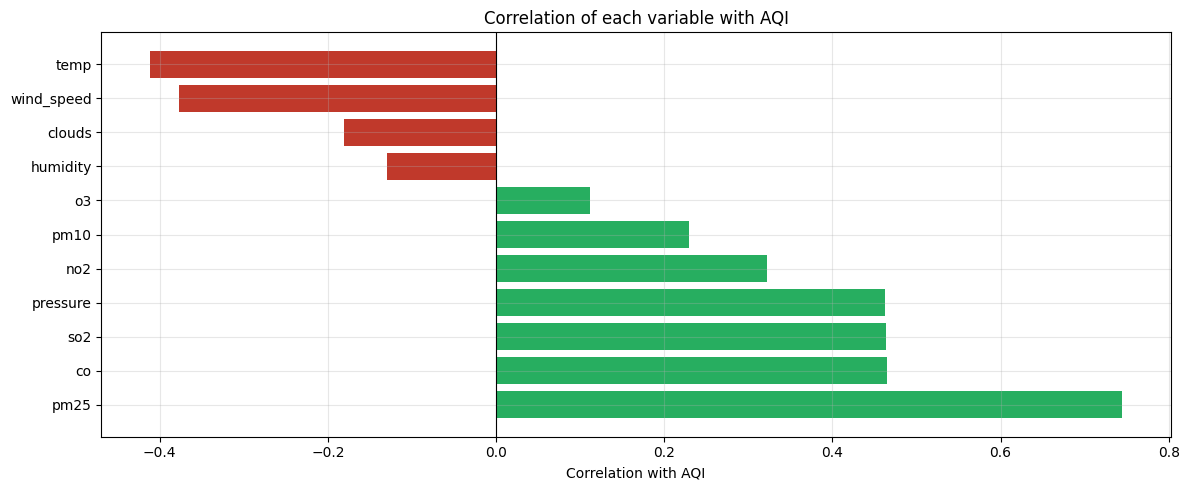

In [ ]:
fig, ax = plt.subplots()
colors_corr = ["#27ae60" if v > 0 else "#c0392b" for v in corr_with_aqi.values]
ax.barh(corr_with_aqi.index, corr_with_aqi.values, color=colors_corr)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlation with AQI")
ax.set_title("Correlation of each variable with AQI")
plt.tight_layout()
plt.show()

**Takeaway:** PM2.5 is by far the strongest single driver of AQI
(0.74) — expected, since PM2.5 is usually the dominant pollutant
behind the AQI calculation itself. Temperature and wind speed are the
strongest *negative* drivers, confirming the seasonal story above:
cooler, stiller conditions trap pollution, while warmer, windier
conditions disperse it.

## 7. Full correlation matrix (heatmap)

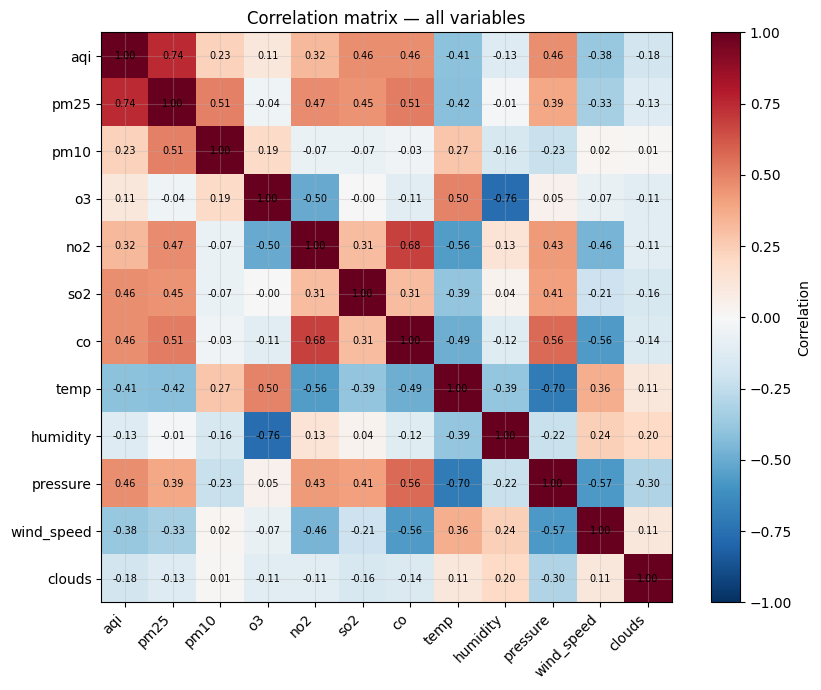

In [ ]:
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im, label="Correlation")
ax.set_title("Correlation matrix — all variables")
plt.tight_layout()
plt.show()

## 9. AQI distribution

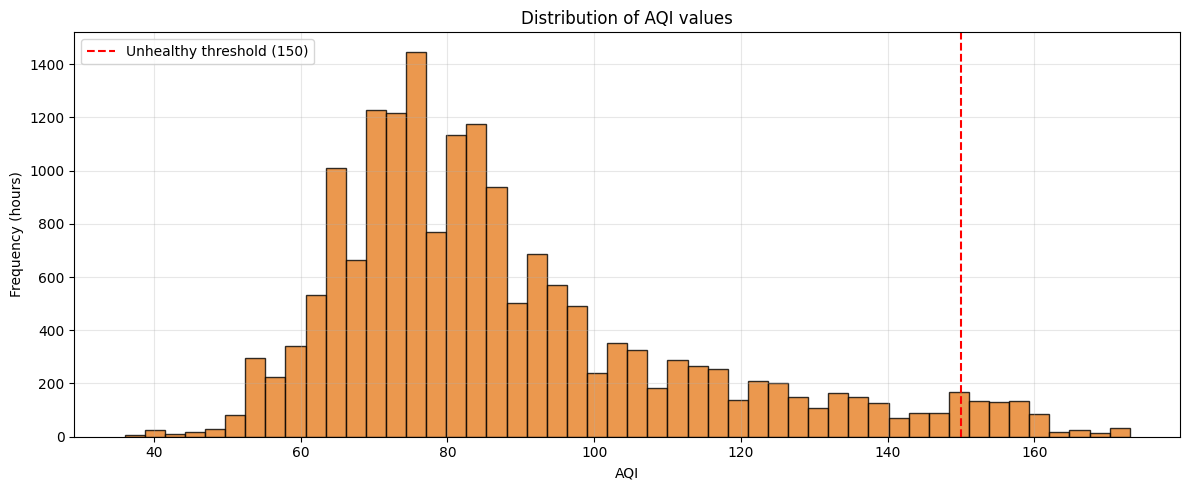

Hours with AQI >= 150: 710 out of 17,544 (4.0%)


In [ ]:
fig, ax = plt.subplots()
ax.hist(df["aqi"], bins=50, color="#e67e22", edgecolor="black", alpha=0.8)
ax.axvline(150, color="red", linestyle="--", label="Unhealthy threshold (150)")
ax.set_xlabel("AQI")
ax.set_ylabel("Frequency (hours)")
ax.set_title("Distribution of AQI values")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Hours with AQI >= 150: {(df['aqi'] >= 150).sum():,} out of {len(df):,} ({100*(df['aqi']>=150).mean():.1f}%)")

## Summary

- **Data quality:** complete, no missing values, physically consistent
  with a comparable regional (Karachi) dataset.
- **Seasonality:** strong — December/January are worst, September is
  cleanest. Justifies keeping `month` as a feature.
- **Daily rhythm:** moderate — evening hours (6-8pm local) consistently
  worse, likely traffic/cooking-driven.
- **Strongest predictors:** PM2.5, CO, SO2 (positive); temperature,
  wind speed (negative).
- **Next step:** use these findings to guide feature selection and
  validate the engineered features in `src/data.py` before training.
